In [230]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys

from itertools import groupby

np.set_printoptions(threshold=sys.maxsize)
# np.set_printoptions(precision=5)
# np.set_printoptions(suppress=True)

In [231]:
voices = np.loadtxt("../F.txt")

In [232]:
voices.shape

(3824, 4)

In [233]:
voices.dtype

dtype('float64')

In [234]:
voices = voices.astype(np.int8)

In [235]:
voices.min(), voices.max()

(0, 76)

In [236]:
voices_df = pd.DataFrame(voices)
print(voices_df[320:335].transpose())

   320  321  322  323  324  325  326  327  328  329  330  331  332  333  334
0   61   61   61   61   61   61   61   61   61   61   61   61   63   63   63
1   59   59   59   59   57   57   56   56   57   57   57   57   57   57   57
2   54   54   54   54   49   49   49   49   54   54   54   54   54   54   54
3    0    0    0    0    0    0    0    0   42   42   42   42   42   42   42


[Text(0.5, 1.0, 'Histogram of note pitch values'), (20.0, 80.0), (0.0, 1200.0)]

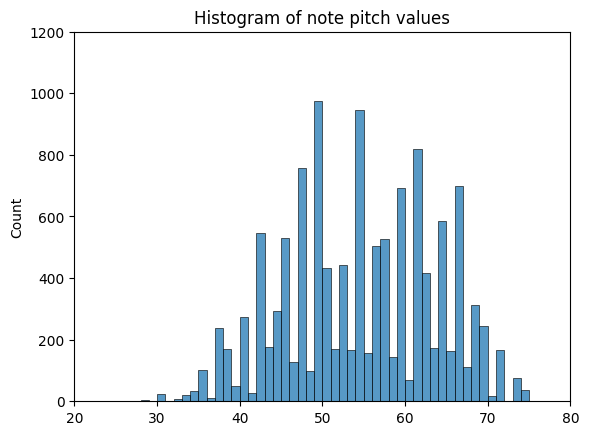

In [237]:
sns.histplot(voices.flatten(), legend=False, binwidth=1).set(title="Histogram of note pitch values", 
                                                             xlim=(20, 80), ylim=(0, 1200))

/tmp/ipykernel_436/748654788.py:6: UserWarning: The label '_no_legend_' of <matplotlib.lines.Line2D object at 0x7f522b03e470> starts with '_'. It is thus excluded from the legend.
  plt.legend(title="Voice", labels=["Soprano", '_no_legend_', "Alto", '_no_legend_', "Tenor", '_no_legend_', "Bass"])
/tmp/ipykernel_436/748654788.py:6: UserWarning: The label '_no_legend_' of <matplotlib.lines.Line2D object at 0x7f522b03e9b0> starts with '_'. It is thus excluded from the legend.
  plt.legend(title="Voice", labels=["Soprano", '_no_legend_', "Alto", '_no_legend_', "Tenor", '_no_legend_', "Bass"])
/tmp/ipykernel_436/748654788.py:6: UserWarning: The label '_no_legend_' of <matplotlib.lines.Line2D object at 0x7f522b03f070> starts with '_'. It is thus excluded from the legend.
  plt.legend(title="Voice", labels=["Soprano", '_no_legend_', "Alto", '_no_legend_', "Tenor", '_no_legend_', "Bass"])


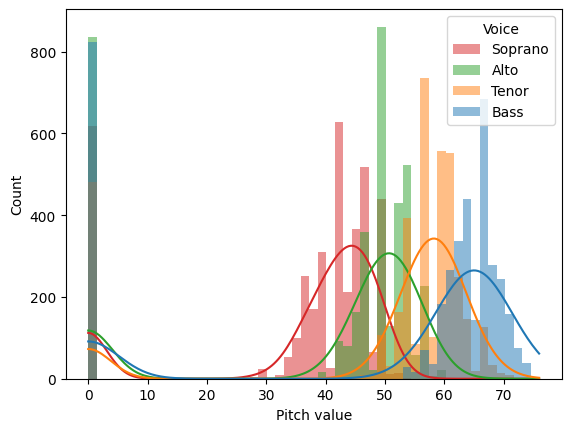

In [238]:
fig, axs = plt.subplots()
# fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# fig.suptitle("Histogram of notes pitch values per voice")
for a in [[voices[:,0], voices[:,1], voices[:,2], voices[:,3]]]:
    sns.histplot(a, ax=axs, kde=True, element="step", edgecolor = "none", alpha=0.5)
    plt.legend(title="Voice", labels=["Soprano", '_no_legend_', "Alto", '_no_legend_', "Tenor", '_no_legend_', "Bass"])
    plt.xlabel("Pitch value")
    

# plt.hist([voices[:,0], voices[:,1], voices[:,2], voices[:,3]])

# sns.histplot(voices[:,0], legend=False, ax=axs[0, 0], binwidth=1).set(title="Soprano", xlim=(20, 80), ylim=(0, 700))
# sns.histplot(voices[:,1], legend=False, ax=axs[0, 1], binwidth=1).set(title="Alto", xlim=(20, 80), ylim=(0, 700))
# sns.histplot(voices[:,2], legend=False, ax=axs[1, 0], binwidth=1).set(title="Tenor", xlim=(20, 80), ylim=(0, 700))
# sns.histplot(voices[:,3], legend=False, ax=axs[1, 1], binwidth=1).set(title="Bass", xlim=(20, 80), ylim=(0, 700))

In [239]:
x_soprano, x_alto, x_tenor, x_bass = np.hsplit(voices, 4)

In [240]:
d_soprano = np.diff(x_soprano[x_soprano != 0], axis=0)
d_alto = np.diff(x_alto[x_alto != 0], axis=0)
d_tenor = np.diff(x_tenor[x_tenor != 0], axis=0)
d_bass = np.diff(x_bass[x_bass != 0], axis=0)

# print(d_bass)

In [241]:
d_total = np.concatenate((d_soprano, d_alto, d_tenor, d_bass))

[Text(0.5, 1.0, 'Histogram of total note deltas'), (-20.0, 20.0)]

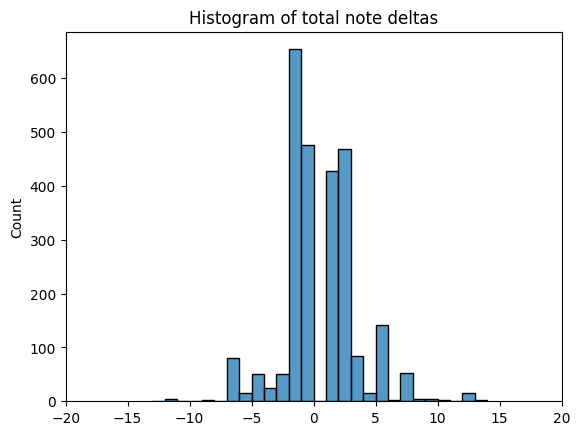

In [242]:
sns.histplot(d_total[d_total != 0], legend=False, binwidth=1).set(title="Histogram of total note deltas", xlim=(-20, 20))

[Text(0.5, 1.0, 'Bass'), (-20.0, 20.0)]

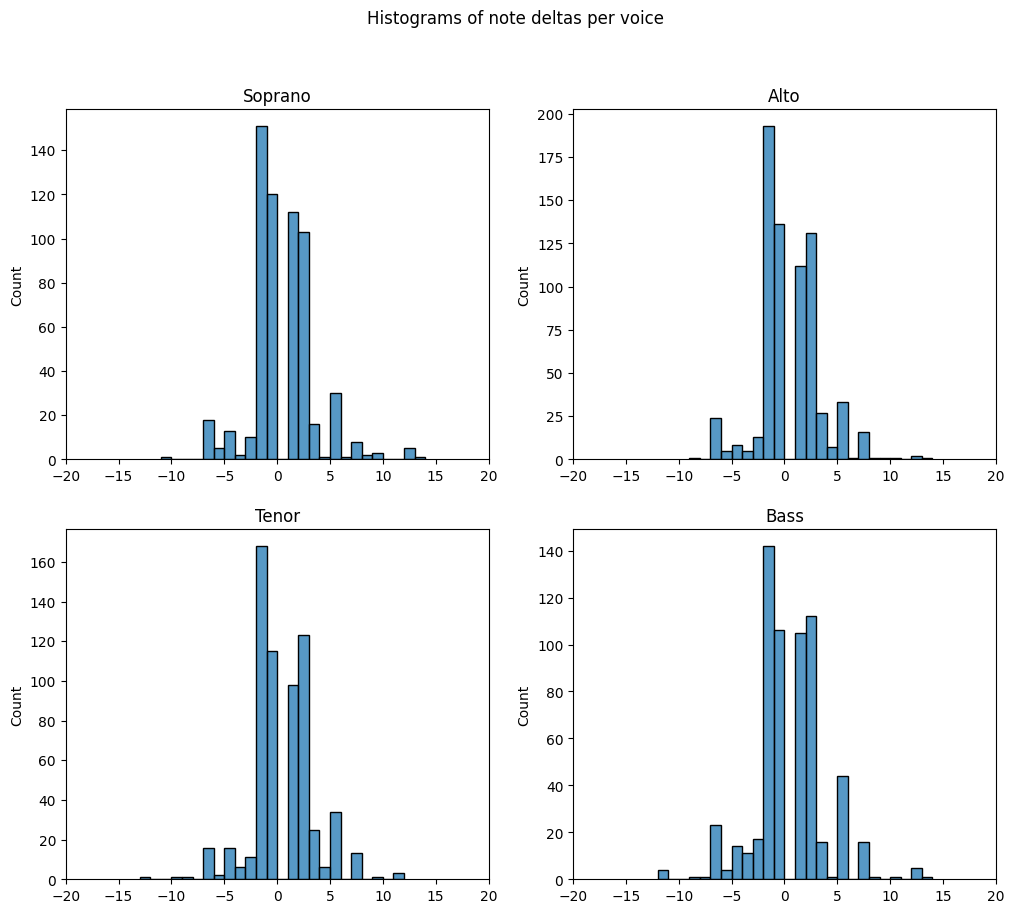

In [243]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
plt.suptitle("Histograms of note deltas per voice")
sns.histplot(d_soprano[d_soprano != 0], legend=False, ax=axs[0, 0], binwidth=1).set(title="Soprano", 
                                                                                xlim=(-20, 20))
sns.histplot(d_alto[d_alto != 0], legend=False, ax=axs[0, 1], binwidth=1).set(title="Alto", 
                                                                                xlim=(-20, 20))
sns.histplot(d_tenor[d_tenor != 0], legend=False, ax=axs[1, 0], binwidth=1).set(title="Tenor", 
                                                                                xlim=(-20, 20))
sns.histplot(d_bass[d_bass != 0], legend=False, ax=axs[1, 1], binwidth=1).set(title="Bass", 
                                                                                xlim=(-20, 20))

In [244]:
note_lengths_soprano = np.asarray([sum(1 for _ in group) for _, group in groupby(x_soprano[x_soprano != 0])], dtype=np.int8)
note_lengths_alto = np.asarray([sum(1 for _ in group) for _, group in groupby(x_alto[x_alto != 0])], dtype=np.int8)
note_lengths_tenor = np.asarray([sum(1 for _ in group) for _, group in groupby(x_tenor[x_tenor != 0])], dtype=np.int8)
note_lengths_bass = np.asarray([sum(1 for _ in group) for _, group in groupby(x_bass[x_bass != 0])], dtype=np.int8)

print(note_lengths_alto)

[ 8 12  4 16 16 16 24 12  4 12  4 12  4  4  8  2  2  8  4  2  2 12  8  6
  2  8  2  2  4  4  8 12  2  2  4  4 12  2  2 12  2  2 12  2  2  8 12  4
 16 16 16 28  8  2  2  8  8 12  4 16 16 16  4  4 12  2  2 12  4 12  4  4
  4  4  4 16  4  4  4  4 16  4  4  4  4  4  4  4  4  8  8 12  4 12  4  6
  2  4  2  2  8  4  2  2  4  2  2 12  2  2 12  2  2  8 12  2  2  4  2  2
 12  2  2  4  4  4  4  4  2  2 16 12  2  2  4  4  4  4 12  2  2 16  8 16
 16 12  4 16 16 16 12  2  2 12  2  2 12  2  2  8 16  8  8  8 12  4 16 16
 16  8  4  2  2  4  4  4  4  4  2  2  4  4 12  2  2 12  2  2  4  4  4  4
  8 12  4 16  4  4  8 16 12  2  2  4  2  2  2  2  8  4  8 12  4 16 16 16
  4  2  2  2  2  4  4  8  2  2  4  4  8  4  2  2  2  2  8  2  2  4  4  8
  8  4 12  2  2  4  4  4  8  2  2  4  6  2  8  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  1  1  2  2  2  2  2  2 10  1  1  2  2 10
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  4  4  6  2  4
  4  4  8  6  2  2  2  2  2  2  2  2  2  2  2  2  2

([<matplotlib.axis.XTick at 0x7f522badde40>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24')])

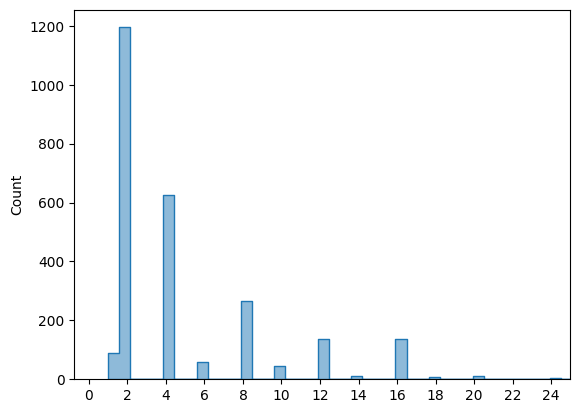

In [251]:
# unique_rest, counts_rest = np.unique(np.concatenate((note_lengths_soprano, note_lengths_alto, note_lengths_tenor)), return_counts=True)
# unique_bass, counts_bass = np.unique(note_lengths_bass, return_counts=True)
# mean_counts_rest = counts_rest/3

note_lengths = np.concatenate((note_lengths_soprano, note_lengths_alto, note_lengths_tenor, note_lengths_bass))
# fig, ax = plt.subplots()
sns.histplot(note_lengths, legend=False, element="step", alpha=0.5)
# sns.histplot([note_lengths, note_lengths_bass], legend=False, element="step", alpha=0.5)
# sns.histplot(x = unique_bass, weights=counts_bass, legend=False, element="step", alpha=0.5)
# sns.histplot(note_lengths_bass, legend=False, element="step", alpha=0.5)
plt.xlim(right=25)
plt.xticks(range(0,25,2))
plt.xlabel("The length of the notes played in 1/6th measure.")
# plt.title("Histogram of total note lengths")


# def tick_formatter(x, pos=None):
#     x = int(x)
#     if x in set(note_lengths):
#         return str(x)
#     return ''

# plt.xticks(range(note_lengths.max()))
# mt = mticker.FuncFormatter(tick_formatter)
# ax.xaxis.set_major_formatter(mt)

[Text(0.5, 1.0, 'Bass')]

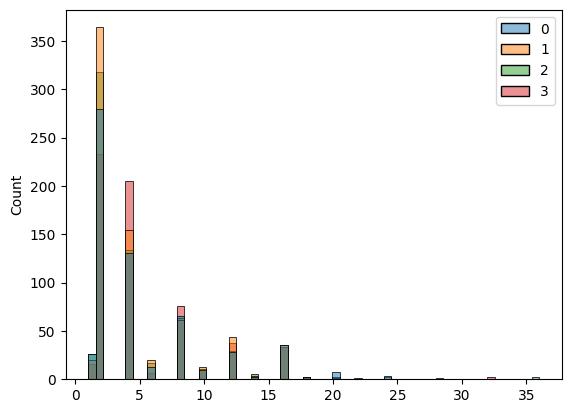

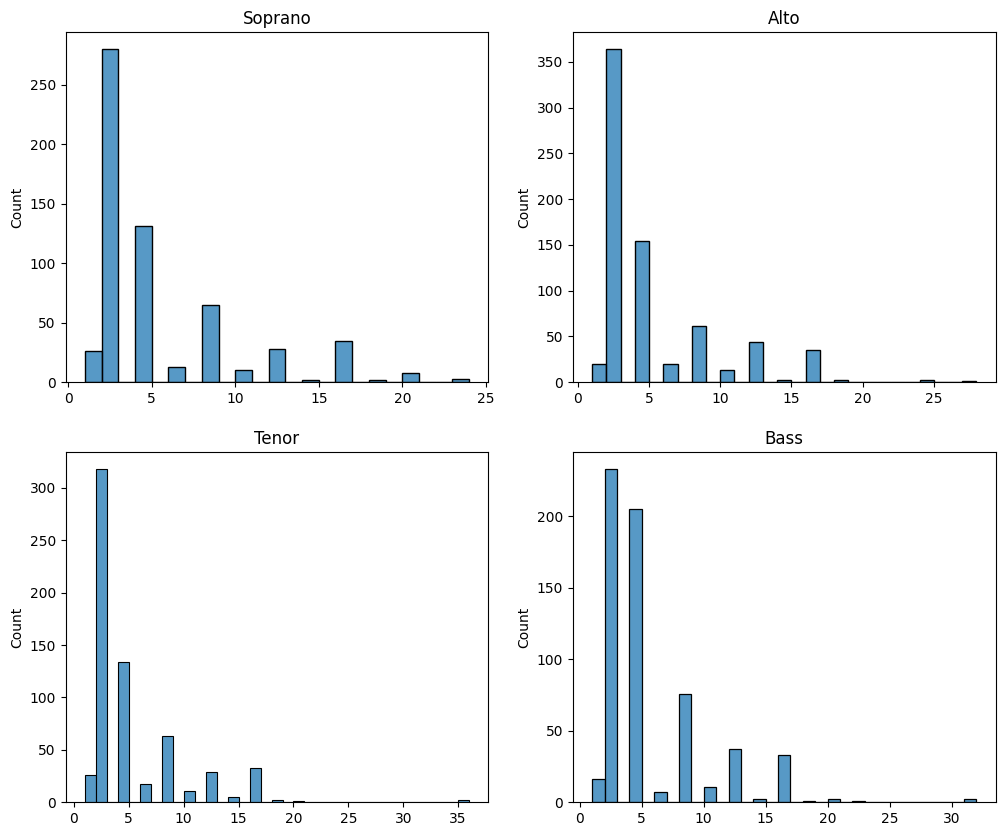

In [246]:
# fig, axs = plt.subplots()
fig.suptitle("Histogram of note lengths per voice")
sns.histplot([note_lengths_soprano, note_lengths_alto, note_lengths_tenor, note_lengths_bass])

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(note_lengths_soprano, legend=False, ax=axs[0, 0], binwidth=1).set(title="Soprano")
sns.histplot(note_lengths_alto, legend=False, ax=axs[0, 1], binwidth=1).set(title="Alto")
sns.histplot(note_lengths_tenor, legend=False, ax=axs[1, 0], binwidth=1).set(title="Tenor")
sns.histplot(note_lengths_bass, legend=False, ax=axs[1, 1], binwidth=1).set(title="Bass")

# mt = mticker.FuncFormatter(tick_formatter)
# for ax in axs.flatten():
#     ax.set_xticks(range(note_lengths.max()))
#     ax.xaxis.set_major_formatter(mt)